In [53]:
import torch

In [54]:
torch.cuda.is_available()

True

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import Dataset
import torchvision.transforms as T
import torch.nn.functional as F 
from PIL import Image
from pathlib import Path
import numpy as np
from typing import Tuple
import matplotlib.pyplot as plt

Class 1: 22524 pixels
Class 3: 7330 pixels
Class 4: 135048 pixels
Class 6: 41009 pixels
Class 7: 842665 pixels
Image shape: (1024, 1024, 3)
Mask shape: (1024, 1024)
Classes: [1 3 4 6 7]


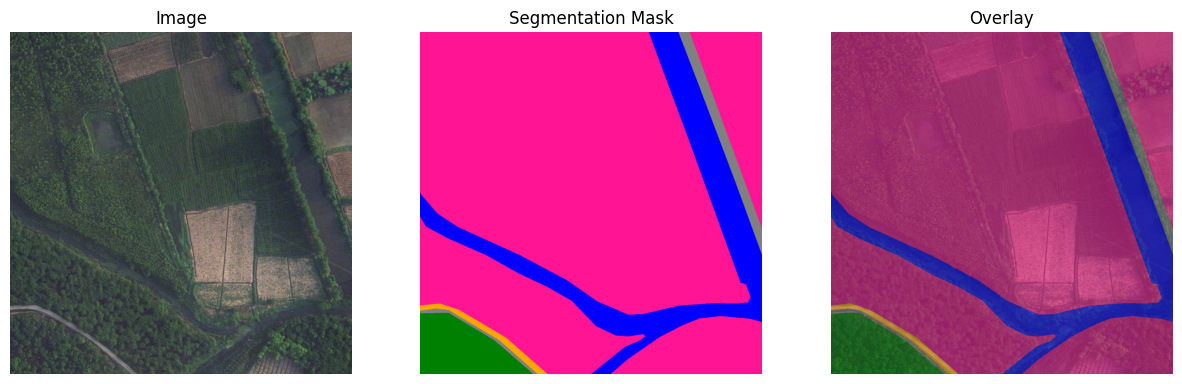

In [56]:
image_path = "/kaggle/input/datasets/mohammedjaveed/loveda-dataset/Train/Train/Rural/images_png/1021.png"
mask_path = "/kaggle/input/datasets/mohammedjaveed/loveda-dataset/Train/Train/Rural/masks_png/1021.png"

image = np.array(Image.open(image_path))
mask = np.array(Image.open(mask_path))

unique, counts = np.unique(mask, return_counts=True)

for value, count in zip(unique, counts):
    print(f"Class {value}: {count} pixels")

print("Image shape:", image.shape)
print("Mask shape:", mask.shape)
print("Classes:", np.unique(mask))

# RGB color for each class
palette = np.array([
    [0, 0, 0],        # 0 - unused
    [128, 128, 128],  # 1 - background
    [255, 0, 0],      # 2 - building
    [255, 165, 0],    # 3 - road (orange)
    [0, 0, 255],      # 4 - water
    [139, 69, 19],    # 5 - barren (brown)
    [0, 128, 0],      # 6 - forest (dark green)
    [255, 20, 147],   # 7 - agriculture (deep pink)
])

colored_mask = palette[mask]

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image)
plt.title("Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(colored_mask)
plt.title("Segmentation Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(image)
plt.imshow(colored_mask, alpha=0.5)
plt.title("Overlay")
plt.axis("off")

plt.show()


In [57]:
def sample_points(mask, points):
    h, w = mask.shape
    ys = np.random.randint(0, h, size=points)
    xs = np.random.randint(0, w, size=points)
    labels = mask[ys, xs]

    return ys, xs, labels

In [58]:
ys, xs, labels = sample_points(
    mask,
    points=100
)

print(ys.shape)
print(xs.shape)
print(labels.shape)

(100,)
(100,)
(100,)


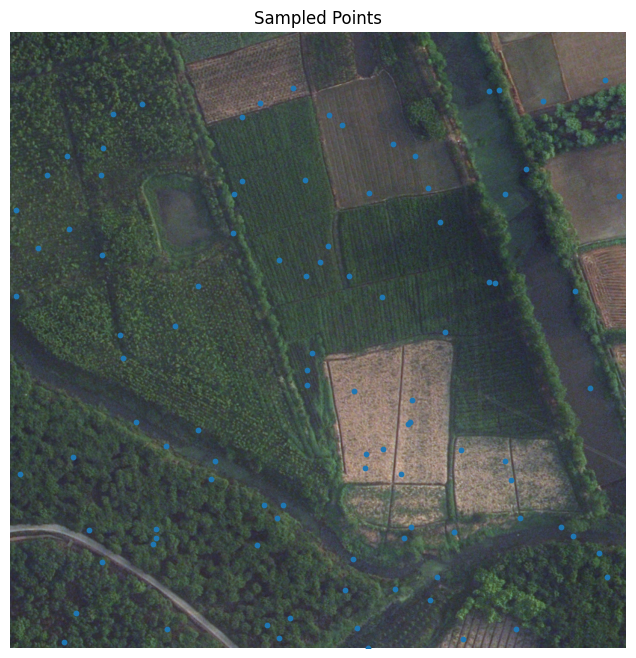

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

plt.imshow(image)

plt.scatter(
    xs,
    ys,
    s=10
)

plt.title("Sampled Points")
plt.axis("off")

plt.show()

In [60]:
classes = np.unique(mask)
classes

array([1, 3, 4, 6, 7], dtype=uint8)

In [61]:
def sample_points_per_class(mask, points_per_class):
    points = []

    classes = np.unique(mask)

    for class_id in classes:

        ys, xs = np.where(mask == class_id)

        if len(ys) == 0:
            continue

        n = min(points_per_class, len(ys))

        indices = np.random.choice(
            len(ys),
            size=n,
            replace=False
        )

        for i in indices:
            points.append(
                (ys[i], xs[i], class_id)
            )

    return np.array(points)

In [62]:
# def sample_point_labels(mask, num_points_per_class=3, ignore_index=255):
#     """
#     Convert a full dense mask [H, W] into a point-label mask.
#     All unlabeled pixels are set to ignore_index (255).
#     """
#     if isinstance(mask, torch.Tensor):
#         mask_np = mask.numpy()
#     else:
#         mask_np = np.array(mask) # if gpu mask.detach().cpu().numpy()
 
#     H, W = mask_np.shape
#     point_mask = np.full((H, W), ignore_index, dtype=np.int64)
 
#     unique_classes = np.unique(mask_np)
#     unique_classes = unique_classes[unique_classes != ignore_index]
 
#     for cls in unique_classes:
#         rows, cols  = np.where(mask_np == cls)
#         n_available = len(rows)
#         n_sample    = min(num_points_per_class, n_available)
#         replace     = n_available < n_sample
#         chosen      = np.random.choice(n_available, size=n_sample, replace=replace)
#         point_mask[rows[chosen], cols[chosen]] = cls
 
#     return torch.tensor(point_mask, dtype=torch.long)

In [63]:
points = sample_points_per_class(
    mask,
    points_per_class=20
)

print(points.shape)

(100, 3)


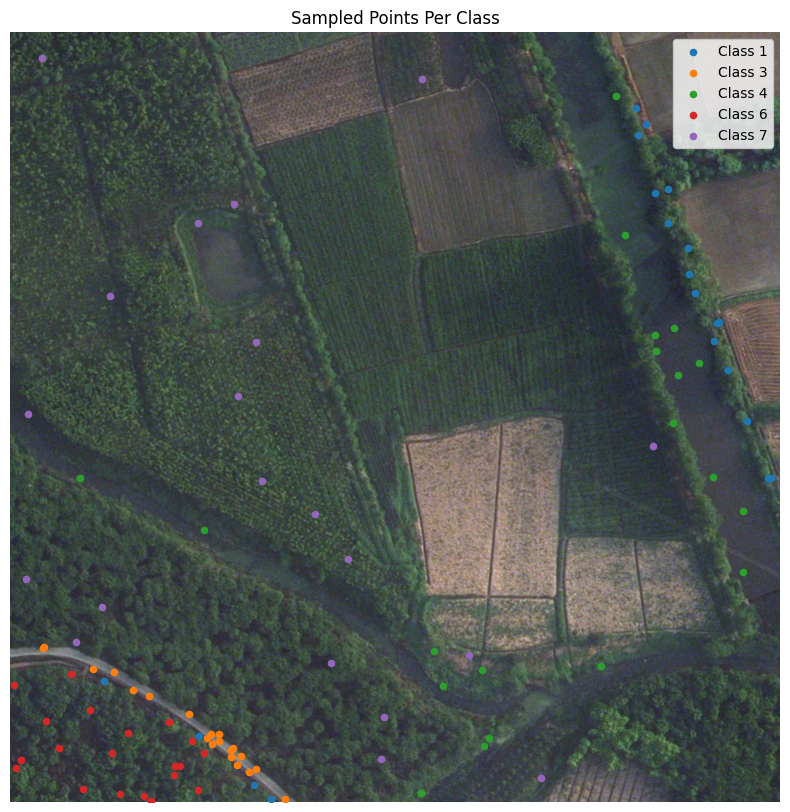

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

plt.imshow(image)

classes = np.unique(points[:, 2])

for class_id in classes:
    class_points = points[points[:, 2] == class_id]

    ys = class_points[:, 0]
    xs = class_points[:, 1]

    plt.scatter(
        xs,
        ys,
        s=20,
        label=f"Class {class_id}"
    )

plt.title("Sampled Points Per Class")
plt.legend()
plt.axis("off")

plt.show()

In [65]:
def sample_point_labels_for_class(
    mask,
    sample_percentage=0.10,
    ignore_index=255
):
    if isinstance(mask, torch.Tensor):
        mask_np = mask.numpy()
    else:
        mask_np = np.array(mask).detach().cpu().numpy() # if gpu mask.detach().cpu().numpy()
     
    H, W = mask_np.shape
    # create a full image with just ignore_index pixel
    point_mask = np.full((H, W), ignore_index, dtype=np.int64)
    unique_classes = np.unique(mask_np)
    unique_classes = unique_classes[unique_classes != ignore_index]

    # loop through you classes
    for cls in unique_classes:
        """
        get the ys, xs for each pixel for this class
        rows = [0, 1, 1]
        cols = [2, 1, 2]
        (0,2)
        (1,1)
        (1,2)
        """
        rows, cols  = np.where(mask_np == cls)
        # number available pixels for each class say 400
        n_available = len(rows)
        # Sample percentage of this class
        n_sample = int(n_available * sample_percentage)
        # decide how may point for each class
        # Make sure we sample at least one pixel
        # if the class exists
        n_sample = max(1, n_sample)
        # Make sure we don't request more pixels
        n_sample    = min(num_points_per_class, n_available)
        # This randomly selects indices from the pixels belonging to the current class.
        chosen      = np.random.choice(n_available, size=n_sample, replace=False)
        # Put the selected points into the new mask
        point_mask[rows[chosen], cols[chosen]] = cls
    
    return torch.tensor(point_mask, dtype=torch.long)
    

In [71]:
import torchvision.transforms as T

image_transform = T.Compose([
    T.Resize((256, 256)),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.ToTensor(),
    # T.Normalize(
    #     mean=[0.485, 0.456, 0.406],
    #     std=[0.229, 0.224, 0.225]
    # )
])

mask_transform = T.Compose([
    T.Resize(
        (256, 256),
        interpolation=T.InterpolationMode.NEAREST
    ),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip()
])

In [72]:
class LoveDADataset(Dataset):
    def __init__(
        self, 
        data_root: str, 
        split: str="Train", 
        transforms: T=None,
        sample_percentage: float = 0.10,
        ignore_index: int = 255,
    ):
        self.data_root = Path(data_root)
        self.split = split
        self.transforms = transforms
        self.sample_percentage = sample_percentage
        self.ignore_index = ignore_index

        self.split_dir = self.data_root / self.split / self.split
        self.data = []

        for domain in ["Rural", "Urban"]:
            image_dir = self.split_dir / domain / "images_png"
            masks_dir = self.split_dir / domain / "masks_png"

            for img_path in image_dir.glob("*.png"):
                mask_path = masks_dir / img_path.name

                if mask_path.exists():
                    self.data.append(
                        (img_path, mask_path)
                    )

        print(f"{split}: {len(self.data)} samples")

    def __len__(self) -> int:
        return len(self.data)


    def __getitem__(self, index) -> Tuple[torch.Tensor, torch.Tensor]:
        img_path, mask_path = self.data[index]

        img = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path)

        # if self.transforms:
        img = image_transform(img)
        mask = mask_transform(mask)

        mask = torch.tensor(np.array(mask), dtype=torch.long)
         # Training → partial point supervision
        if self.split.lower() == "train":

            target = sample_point_labels_for_class(
                mask,
                sample_percentage=self.sample_percentage,
                ignore_index=self.ignore_index,
            )

        # Validation → full ground-truth mask
        else:
            target = mask

        return img, target

In [75]:
dataset = LoveDADataset("/kaggle/input/datasets/mohammedjaveed/loveda-dataset")

image, point_mask = dataset[7]

print(image.shape)
print(point_mask.shape)
print(torch.unique(point_mask, return_counts=True))

Train: 2522 samples
torch.Size([3, 256, 256])
torch.Size([256, 256])
(tensor([  1,   2,   4,   6, 255]), tensor([   20,    20,    20,    20, 65456]))


Number of sampled points: 80
Classes: [1 2 4 6]


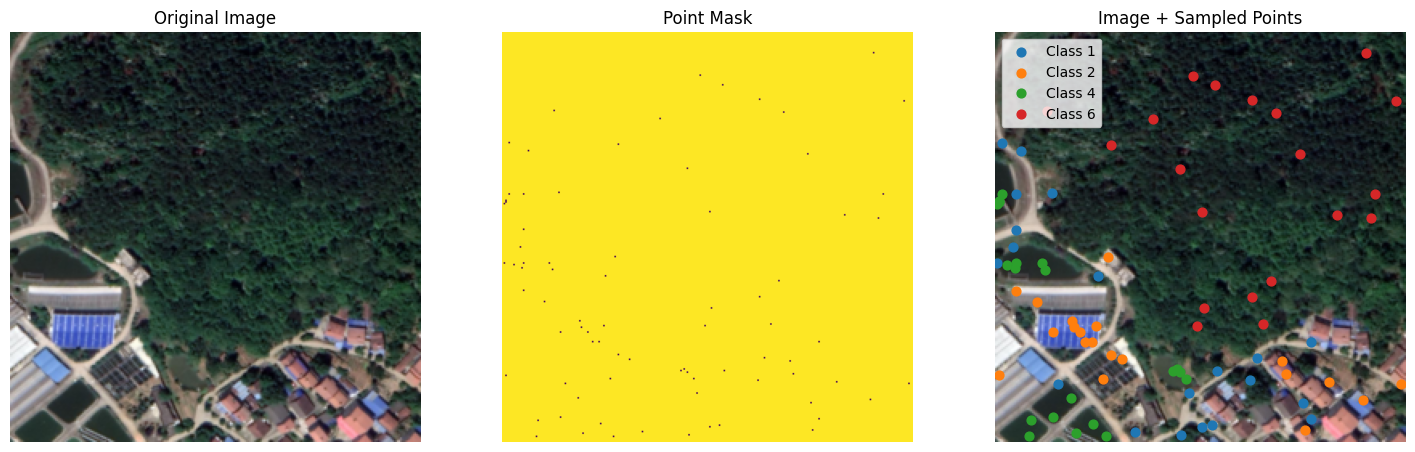

In [77]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Convert image to numpy
if isinstance(image, torch.Tensor):
    image_np = image.permute(1, 2, 0).cpu().numpy()
else:
    image_np = np.array(image)

# Convert point mask to numpy
point_mask_np = point_mask.cpu().numpy()

# Find sampled points
ys, xs = np.where(point_mask_np != 255)

# Get their class labels
labels = point_mask_np[ys, xs]

print("Number of sampled points:", len(xs))
print("Classes:", np.unique(labels))

plt.figure(figsize=(18, 6))

# -------------------------
# 1. Original image
# -------------------------
plt.subplot(1, 3, 1)

plt.imshow(image_np)
plt.title("Original Image")
plt.axis("off")


# -------------------------
# 2. Point mask
# -------------------------
plt.subplot(1, 3, 2)

plt.imshow(point_mask_np)
plt.title("Point Mask")
plt.axis("off")


# -------------------------
# 3. Image + points
# -------------------------
plt.subplot(1, 3, 3)

plt.imshow(image_np)

# Different color for each class
classes = np.unique(labels)

for cls in classes:

    class_indices = labels == cls

    plt.scatter(
        xs[class_indices],
        ys[class_indices],
        s=40,
        label=f"Class {cls}"
    )

plt.title("Image + Sampled Points")
plt.legend()
plt.axis("off")

plt.show()

In [ ]:
"""
model logits: 
logits.shape
[B, C, H, W]
[2, 7, 256, 256]

Convert logits to log-probabilities:
So we apply softmax across the class dimension.
log_probs = F.log_softmax(logits, dim=1) 1 for C # output is [B, C, H, W] too

Find pixels that only have label not 255
255 = ignore
0,1,2,3,4,5,6 = valid class labels
valid = target != 255


[B,C,H,W] logits
       ↓
   log_softmax
       ↓
[B,H,W,C]
       ↓
find target != 255
       ↓
keep only sampled points
       ↓
select correct class
       ↓
negative log probability
       ↓
mean
       ↓
   PCE loss

[N, C]
where N is the number of sampled points.
For example:
point_log_probs:
[
  [logP0, logP1, logP2, ...],
  [logP0, logP1, logP2, ...],
  [logP0, logP1, logP2, ...],
  [logP0, logP1, logP2, ...]
]
"""

In [79]:
def partial_cross_entropy(logits, target, ignore_index=255):

    log_probs = F.log_softmax(logits, dim=1)

    valid = target != ignore_index

    if not valid.any():
        return logits.sum() * 0.0

    labels = target[valid]

    log_probs = log_probs.permute(0, 2, 3, 1)

    point_log_probs = log_probs[valid]

    point_log_probs = point_log_probs[
        torch.arange(point_log_probs.size(0), device=logits.device),
        labels
    ]

    losses = -point_log_probs

    return losses.mean()

In [80]:
import torch
import torch.nn.functional as F

# Dummy segmentation data
B = 2       # batch size
C = 7       # number of classes
H = 256
W = 256

# Model predictions
logits = torch.randn(B, C, H, W)

# Ground-truth labels: values 0-6
target = torch.randint(0, C, (B, H, W))

# Add some ignored pixels
target[0, 0, 0] = 255
target[1, 2, 2] = 255

print("Logits shape:", logits.shape)
print("Target shape:", target.shape)
print("Target:")
print(target)

# Your Partial Cross Entropy
pce_loss = partial_cross_entropy(logits, target)

# Standard Cross Entropy
ce_loss = F.cross_entropy(
    logits,
    target,
    ignore_index=255
)

print("\nPartial CE:", pce_loss.item())
print("Standard CE:", ce_loss.item())

Logits shape: torch.Size([2, 7, 4, 4])
Target shape: torch.Size([2, 4, 4])
Target:
tensor([[[255,   4,   6,   4],
         [  5,   0,   0,   2],
         [  2,   5,   2,   6],
         [  4,   6,   0,   5]],

        [[  4,   4,   2,   1],
         [  2,   4,   4,   6],
         [  2,   4, 255,   3],
         [  2,   0,   6,   5]]])

Partial CE: 2.304114818572998
Standard CE: 2.304114818572998


In [ ]:
logits = torch.randn(2, 7, 256, 256)
log_probs = F.log_softmax(logits, dim=1)
log_probs.shape

In [ ]:
class PartialCrossEntropyLoss(nn.Module):
    def __init__(self, ignore_index=255):
        super().__init__()
        self.ignore_index = ignore_index

    def forward(self, predictions, targets):
        # predictions -> [B, C, H, W]
        log_probs = f.log_softmax(predictions) # -> [B, C, H, W]

        # get the valid samples of the target
        valid = target != self.ignore_index
        # No labeled pixels
        if not valid.any():
            return logits.sum() * 0.0

        # Ground-truth labels of sampled pixels
        labels = target[valid]
        # [B, C, H, W] -> [B, H, W, C]
        log_probs = log_probs.permute(0, 2, 3, 1)
        
        # Keep only sampled pixels
        point_log_probs = log_probs[valid]
        
        # Select probability of the correct class
        point_log_probs = point_log_probs[
            torch.arange(
                point_log_probs.size(0),
                device=predictions.device
            ),
            labels
        ]
        
        # Cross entropy = -log(P(correct class))
        losses = -point_log_probs

        # Average over sampled points
        return losses.mean()